# Блок 3. Кластеризация на новом датасете

Используется датасет `Iris` из `scikit-learn`.

Сравниваются четыре алгоритма кластеризации:

1. `k-means` со случайной инициализацией центров.
2. `k-means++`.
3. `DBSCAN`.
4. `Mean Shift`.

Цель: по четырём числовым признакам ириса разбить объекты на естественные группы без использования меток при обучении.
Истинные виды используются только после обучения для анализа качества кластеризации.

## О датасете Iris

Датасет `Iris` - один из самых известных учебных наборов данных в машинном обучении.
Он содержит измерения цветков ириса трёх разных видов и часто используется для задач
классификации, кластеризации и визуального анализа многомерных данных.

В наборе `150` наблюдений и `4` числовых признака. Каждый объект - это отдельный цветок,
для которого измерены размеры двух частей растения:

- чашелистика (`sepal`);
- лепестка (`petal`).

Истинные метки соответствуют трём видам ириса:

- `setosa`;
- `versicolor`;
- `virginica`.

Всего в датасете по `50` объектов каждого вида, поэтому классы полностью сбалансированы.
Это удобно для анализа: различия в результатах моделей связаны именно со структурой данных,
а не с перекосом по числу наблюдений.

Признаки:

- `sepal length (cm)` - длина чашелистика;
- `sepal width (cm)` - ширина чашелистика;
- `petal length (cm)` - длина лепестка;
- `petal width (cm)` - ширина лепестка.

Содержательно задача выглядит так: по геометрическим характеристикам цветка нужно понять,
образуют ли наблюдения естественные группы, соответствующие ботаническим видам.
Этот датасет хорошо подходит для кластеризации, потому что один вид (`setosa`) отделяется
довольно чётко, а два других (`versicolor` и `virginica`) частично пересекаются.
Из-за этого на нём удобно сравнивать алгоритмы: видно и сильные стороны метода,
и его ограничения на данных с неполным разделением групп.

Для кластеризации метки не подаются в модель. Они используются только после обучения,
чтобы проверить, насколько найденные кластеры похожи на реальные виды растений.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans, DBSCAN, MeanShift, estimate_bandwidth
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

sns.set_theme(style="whitegrid")

iris = load_iris(as_frame=True)
df_iris = iris.frame.copy()
target_map = {idx: name for idx, name in enumerate(iris.target_names)}
df_iris["target_name"] = df_iris["target"].map(target_map)
feature_cols = iris.feature_names

print(f"Размер датасета: {df_iris.shape}")
display(df_iris.head())

Размер датасета: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Первичный анализ и исследование данных

Проверяются:

1. структура таблицы;
2. отсутствие пропусков;
3. распределение истинных видов;
4. описательная статистика;
5. связи между признаками.

Хотя задача является несупервизорной, информация о видах полезна для интерпретации результатов после кластеризации.

Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   target_name        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Пропуски по столбцам:



,missing_count
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
target_name,0



Распределение истинных видов:



,count
target_name,
setosa,50
versicolor,50
virginica,50



Описательная статистика:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


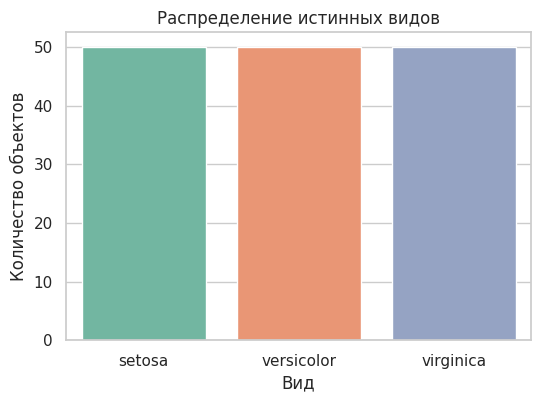

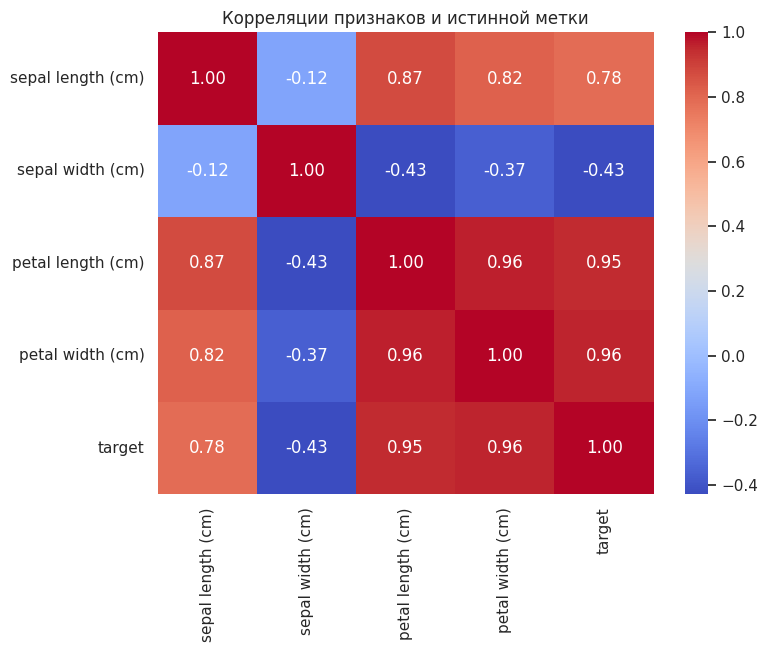

In [2]:
print("Информация о датасете:\n")
df_iris.info()

print("\nПропуски по столбцам:\n")
display(df_iris.isna().sum().to_frame(name="missing_count"))

print("\nРаспределение истинных видов:\n")
display(df_iris["target_name"].value_counts().to_frame(name="count"))

print("\nОписательная статистика:\n")
display(df_iris[feature_cols].describe())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_iris, x="target_name", hue="target_name", palette="Set2", legend=False)
plt.title("Распределение истинных видов")
plt.xlabel("Вид")
plt.ylabel("Количество объектов")
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df_iris[feature_cols + ["target"]].corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Корреляции признаков и истинной метки")
plt.show()

## Подготовка данных и обучение моделей

Перед кластеризацией признаки стандартизуются.
Это особенно важно для расстояний в `KMeans`, `DBSCAN` и `Mean Shift`.

Дополнительно строится проекция `PCA` в двумерное пространство для визуализации кластеров.
Сами алгоритмы работают на полном стандартизованном пространстве из четырёх признаков.

Для `DBSCAN` параметры `eps` и `min_samples` подбираются перебором по небольшой сетке.
Качество конфигурации оценивается по `silhouette_score` на объектах без шума.

Для `Mean Shift` ширина окна оценивается автоматически через `estimate_bandwidth`.

In [3]:
X = df_iris[feature_cols]
y_true = df_iris["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["target_name"] = df_iris["target_name"].values


def count_clusters(labels):
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    return int(np.sum(unique_labels != -1))


def safe_internal_metrics(X_values, labels, ignore_noise=False):
    labels = np.asarray(labels)
    X_eval = X_values
    labels_eval = labels

    if ignore_noise:
        mask = labels != -1
        X_eval = X_values[mask]
        labels_eval = labels[mask]

    unique_labels = np.unique(labels_eval)
    if len(unique_labels) < 2 or len(labels_eval) <= len(unique_labels):
        return np.nan, np.nan, np.nan

    return (
        silhouette_score(X_eval, labels_eval),
        davies_bouldin_score(X_eval, labels_eval),
        calinski_harabasz_score(X_eval, labels_eval),
    )


def build_result(name, labels, X_values, y_reference, inertia=np.nan, iterations=np.nan, ignore_noise=False):
    silhouette, davies, calinski = safe_internal_metrics(X_values, labels, ignore_noise=ignore_noise)
    return {
        "Алгоритм": name,
        "Кластеры": count_clusters(labels),
        "Шум": float(np.mean(np.asarray(labels) == -1)),
        "Silhouette": silhouette,
        "Davies-Bouldin": davies,
        "Calinski-Harabasz": calinski,
        "ARI": adjusted_rand_score(y_reference, labels),
        "Inertia": inertia,
        "Iterations": iterations,
    }


model_kmeans_random = KMeans(
    n_clusters=3,
    init="random",
    n_init=10,
    max_iter=300,
    random_state=42,
)
labels_kmeans_random = model_kmeans_random.fit_predict(X_scaled)

model_kmeans_plus = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    max_iter=300,
    random_state=42,
)
labels_kmeans_plus = model_kmeans_plus.fit_predict(X_scaled)

dbscan_candidates = []
for eps in np.arange(0.3, 1.01, 0.1):
    eps = float(np.round(eps, 1))
    for min_samples in [3, 4, 5, 6]:
        dbscan_model = DBSCAN(eps=eps, min_samples=min_samples)
        labels_dbscan_candidate = dbscan_model.fit_predict(X_scaled)
        silhouette, _, _ = safe_internal_metrics(X_scaled, labels_dbscan_candidate, ignore_noise=True)

        if np.isnan(silhouette):
            continue

        dbscan_candidates.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "silhouette": silhouette,
                "noise_share": float(np.mean(labels_dbscan_candidate == -1)),
                "clusters": count_clusters(labels_dbscan_candidate),
            }
        )

if not dbscan_candidates:
    raise ValueError("Не удалось подобрать валидную конфигурацию DBSCAN на заданной сетке параметров.")

dbscan_search_df = pd.DataFrame(dbscan_candidates).sort_values(
    by=["silhouette", "noise_share", "eps"],
    ascending=[False, True, True],
).reset_index(drop=True)

best_dbscan = dbscan_search_df.iloc[0]
model_dbscan = DBSCAN(eps=float(best_dbscan["eps"]), min_samples=int(best_dbscan["min_samples"]))
labels_dbscan = model_dbscan.fit_predict(X_scaled)

bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=len(X_scaled))
if not np.isfinite(bandwidth) or bandwidth <= 0:
    bandwidth = 1.0

model_meanshift = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_meanshift = model_meanshift.fit_predict(X_scaled)

results_df = pd.DataFrame(
    [
        build_result(
            "KMeans (random)",
            labels_kmeans_random,
            X_scaled,
            y_true,
            inertia=model_kmeans_random.inertia_,
            iterations=model_kmeans_random.n_iter_,
        ),
        build_result(
            "KMeans (k-means++)",
            labels_kmeans_plus,
            X_scaled,
            y_true,
            inertia=model_kmeans_plus.inertia_,
            iterations=model_kmeans_plus.n_iter_,
        ),
        build_result(
            "DBSCAN",
            labels_dbscan,
            X_scaled,
            y_true,
            ignore_noise=True,
        ),
        build_result(
            "Mean Shift",
            labels_meanshift,
            X_scaled,
            y_true,
            iterations=np.nan,
        ),
    ]
).sort_values(by=["ARI", "Silhouette"], ascending=False).reset_index(drop=True)

results_display = results_df.copy()
for col in ["Шум", "Silhouette", "Davies-Bouldin", "Calinski-Harabasz", "ARI", "Inertia"]:
    results_display[col] = results_display[col].round(4)

print("Лучшие параметры DBSCAN:")
print(
    f"eps = {best_dbscan['eps']}, min_samples = {int(best_dbscan['min_samples'])}, "
    f"clusters = {int(best_dbscan['clusters'])}, noise_share = {best_dbscan['noise_share']:.4f}"
)
print(f"\nОценённый bandwidth для Mean Shift: {bandwidth:.4f}")

print("\nТоп конфигураций DBSCAN по silhouette:")
display(dbscan_search_df.head())

print("\nСравнение алгоритмов:")
display(results_display)

Лучшие параметры DBSCAN:
eps = 0.5, min_samples = 5, clusters = 2, noise_share = 0.2267

Оценённый bandwidth для Mean Shift: 1.2070

Топ конфигураций DBSCAN по silhouette:


,eps,min_samples,silhouette,noise_share,clusters
0,0.5,5,0.655889,0.226667,2
1,0.5,4,0.655006,0.220000,2
2,0.6,6,0.645786,0.193333,2
3,0.6,5,0.641895,0.173333,2
4,0.3,5,0.630176,0.800000,3



Сравнение алгоритмов:


,Алгоритм,Кластеры,Шум,Silhouette,Davies-Bouldin,Calinski-Harabasz,ARI,Inertia,Iterations
0,KMeans (k-means++),3,0.0000,0.4599,0.8336,241.9044,0.6201,139.8205,4.0
1,KMeans (random),3,0.0000,0.4594,0.8340,241.8933,0.6101,139.8254,5.0
2,Mean Shift,3,0.0000,0.4325,0.8131,163.7138,0.5600,NaN,NaN
3,DBSCAN,2,0.2267,0.6559,0.4942,343.9681,0.4421,NaN,NaN


## Визуализация кластеров и сравнение с истинными видами

На графиках ниже объекты отображаются в двумерном пространстве `PCA`.
Это не пространство, в котором обучались алгоритмы, а только удобная проекция для визуального анализа.

Для `DBSCAN` серым цветом показывается шум.
Для `KMeans` и `Mean Shift` дополнительно отмечаются центры кластеров.

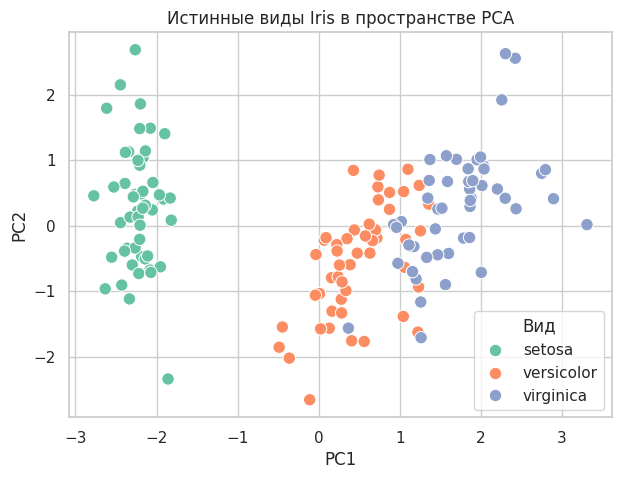

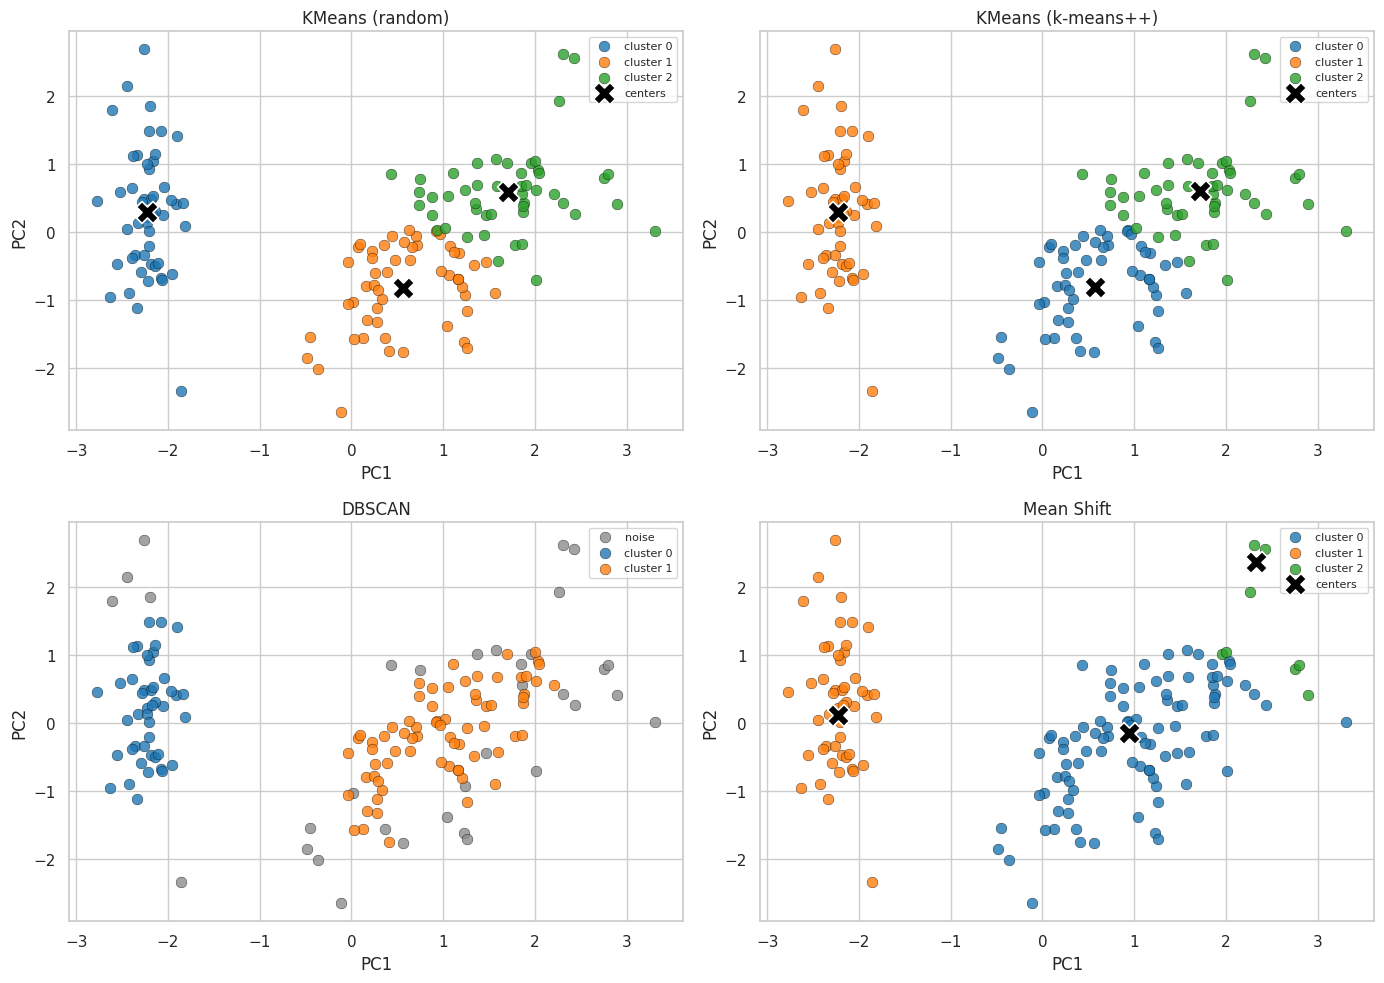

KMeans (random)


Кластер,0,1,2
Истинный вид,,,
setosa,50,0,0
versicolor,0,38,12
virginica,0,14,36


KMeans (k-means++)


Кластер,0,1,2
Истинный вид,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


DBSCAN


Кластер,-1,0,1
Истинный вид,,,
setosa,5,45,0
versicolor,11,0,39
virginica,18,0,32


Mean Shift


Кластер,0,1,2
Истинный вид,,,
setosa,0,50,0
versicolor,50,0,0
virginica,42,0,8


In [4]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="target_name", palette="Set2", s=80)
plt.title("Истинные виды Iris в пространстве PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Вид")
plt.show()


def plot_clusters(ax, points, labels, title, centers=None):
    labels = np.asarray(labels)
    unique_labels = sorted(np.unique(labels))
    palette = sns.color_palette("tab10", n_colors=max(len([label for label in unique_labels if label != -1]), 3))

    color_map = {}
    palette_idx = 0
    for label in unique_labels:
        if label == -1:
            color_map[label] = (0.55, 0.55, 0.55)
        else:
            color_map[label] = palette[palette_idx % len(palette)]
            palette_idx += 1

    for label in unique_labels:
        mask = labels == label
        label_name = "noise" if label == -1 else f"cluster {label}"
        ax.scatter(
            points[mask, 0],
            points[mask, 1],
            s=60,
            alpha=0.8,
            c=[color_map[label]],
            edgecolors="black",
            linewidths=0.3,
            label=label_name,
        )

    if centers is not None:
        centers_pca = pca.transform(centers)
        ax.scatter(
            centers_pca[:, 0],
            centers_pca[:, 1],
            marker="X",
            s=250,
            c="black",
            edgecolors="white",
            linewidths=1.2,
            label="centers",
        )

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend(fontsize=8)


fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plot_clusters(axs[0, 0], X_pca, labels_kmeans_random, "KMeans (random)", centers=model_kmeans_random.cluster_centers_)
plot_clusters(axs[0, 1], X_pca, labels_kmeans_plus, "KMeans (k-means++)", centers=model_kmeans_plus.cluster_centers_)
plot_clusters(axs[1, 0], X_pca, labels_dbscan, "DBSCAN")
plot_clusters(axs[1, 1], X_pca, labels_meanshift, "Mean Shift", centers=model_meanshift.cluster_centers_)

plt.tight_layout()
plt.show()

cluster_labels = {
    "KMeans (random)": labels_kmeans_random,
    "KMeans (k-means++)": labels_kmeans_plus,
    "DBSCAN": labels_dbscan,
    "Mean Shift": labels_meanshift,
}

for model_name, labels in cluster_labels.items():
    print(model_name)
    display(
        pd.crosstab(
            df_iris["target_name"],
            labels,
            rownames=["Истинный вид"],
            colnames=["Кластер"],
            dropna=False,
        )
    )

## Вывод

По графику истинных классов в пространстве `PCA` видно, что `setosa` отделяется хорошо,
а `versicolor` и `virginica` частично перекрываются. Это полностью подтверждается
результатами всех алгоритмов и таблицами соответствия кластеров истинным видам.

Лучший итоговый результат в этой постановке показал `KMeans (k-means++)`:

- найдено `3` кластера без шума;
- получен наибольший `ARI = 0.6201`;
- `Silhouette = 0.4599`, `Davies-Bouldin = 0.8336`, `Calinski-Harabasz = 241.9044`;
- качество немного выше, чем у `KMeans (random)`, а число итераций меньше (`4` против `5`).

`KMeans (random)` дал практически ту же структуру кластеров: `setosa` выделяется идеально,
а основные ошибки возникают между `versicolor` и `virginica`. Разница между двумя вариантами
`k-means` небольшая, но `k-means++` оказался немного стабильнее и эффективнее.

`DBSCAN` получил лучшие внутренние метрики (`Silhouette = 0.6559`, `Davies-Bouldin = 0.4942`),
но этот результат нельзя трактовать как безусловно лучший. Алгоритм нашёл только `2` кластера
и пометил `22.67%` объектов как шум. По таблице видно, что он в основном отделяет `setosa`
от остальных наблюдений, а часть объектов `versicolor` и `virginica` уходит в шум.
Поэтому высокие внутренние метрики здесь отражают качество плотных ядер после исключения шума,
а не лучшее восстановление трёх реальных видов.

`Mean Shift` нашёл `3` кластера без шума, но разделил данные хуже: все объекты `versicolor`
и большая часть `virginica` попали в один кластер, а отдельный третий кластер выделился только
для небольшой части `virginica`. Это согласуется с более низким `ARI = 0.5600`.

Итог: для датасета `Iris` наиболее удачным из рассмотренных методов оказался `KMeans (k-means++)`,
поскольку он лучше остальных согласуется с истинной структурой данных и находит естественные
три группы без выделения большого числа шумовых объектов. `DBSCAN` полезен как метод поиска
плотных областей и шума, но в этой задаче он решает немного другую подзадачу, чем восстановление
трёх ботанических видов.